In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-12 13:22:49.784884


# annotate genes wih original categories during design and export umaps

### Setup

In [2]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

import warnings
import session_info
import sys

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning) # Suppress Pandas PerformanceWarnings related to fragmentation

plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 300

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = os.path.join(base_dir, 'data/h5ad/export_03')
input_dir_2 = os.path.join(base_dir, 'data/h5ad/export_02') # anndata without the transgenes removed

clusters_dir = os.path.join(base_dir, 'clusters')
output_dir = os.path.join(base_dir, 'data/h5ad/export_03/')
#fig_dir = os.path.join(base_dir, 'figures/umap')

os.makedirs(clusters_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

## Read adata

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi-leiden-all.h5ad'))
adata


AnnData object with n_obs × n_vars = 95966 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_colors', 'log1p', 'neighbors', 'output_id_colors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

In [6]:
csv_path = base_dir / "metadata/panel/gene-annotation.csv"

genes = pd.read_csv(csv_path)

In [7]:
genes

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,neuron_detection_rate,glia_detection_rate,combined_detection_rate_mean
0,Pdcd1,ENSMUSG00000026285,8,True,True,False,False,False,False,False,False,NaN,0.000000,0.000000
1,Thy1,ENSMUSG00000032011,8,True,True,False,False,False,False,False,False,34.187716,10.747883,22.467799
2,Adcyap1,ENSMUSG00000024256,8,True,False,False,False,False,False,False,False,36.862709,0.889777,18.876243
3,Adra2a,ENSMUSG00000033717,8,True,False,False,False,False,False,False,False,4.809395,0.646754,2.728075
4,Asic1,ENSMUSG00000023017,8,True,False,False,False,False,False,False,False,12.405630,0.764346,6.584988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,Pvalb,ENSMUSG00000005716,8,False,False,False,False,False,False,False,True,19.051170,12.441204,15.746187
471,Snhg11,ENSMUSG00000044349,8,False,False,False,False,False,False,False,True,98.713766,7.329884,53.021825
472,Tmem56,ENSMUSG00000028132,8,False,False,False,False,False,False,False,True,52.139062,8.000157,30.069610
473,Trappc3l,ENSMUSG00000071340,8,False,False,False,False,False,False,False,True,12.666605,3.406240,8.036422


In [8]:
def merge_var_annotations(adata, annotation_df, gene_col="Gene", fill_missing=True):
    adata.var.index = adata.var.index.astype(str)
    annotation_df[gene_col] = annotation_df[gene_col].astype(str)
    merge_df = annotation_df.set_index(gene_col)
    adata.var = adata.var.join(merge_df, how="left")
    return adata

In [9]:
adata = merge_var_annotations(adata, genes, gene_col="Gene")

In [10]:
adata.var

,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,neuron_detection_rate,glia_detection_rate,combined_detection_rate_mean
1500009L16Rik,ENSMUSG00000087651,8.0,False,False,True,False,False,False,False,False,27.775189,1.959862,14.867525
6330403K07Rik,ENSMUSG00000018451,8.0,False,False,False,False,False,False,False,True,68.244944,5.809031,37.026987
Abcb1a,ENSMUSG00000040584,8.0,False,False,False,False,False,False,True,False,0.960015,15.004704,7.982359
Ache,ENSMUSG00000023328,8.0,False,False,False,False,False,False,True,False,18.361450,0.901537,9.631493
Acta2,ENSMUSG00000035783,5.0,False,False,False,False,False,False,True,False,0.466027,1.583569,1.024798
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vwf,ENSMUSG00000001930,8.0,False,False,False,False,False,False,True,False,0.615155,3.696300,2.155727
Wfdc18,ENSMUSG00000000983,6.0,False,False,False,False,False,True,False,False,0.233013,2.826121,1.529567
Zfp691,ENSMUSG00000045268,8.0,False,False,False,True,False,False,False,False,3.979868,0.642835,2.311351
mCherry_Seq3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
adata.obs.columns
adata

AnnData object with n_obs × n_vars = 95966 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_c

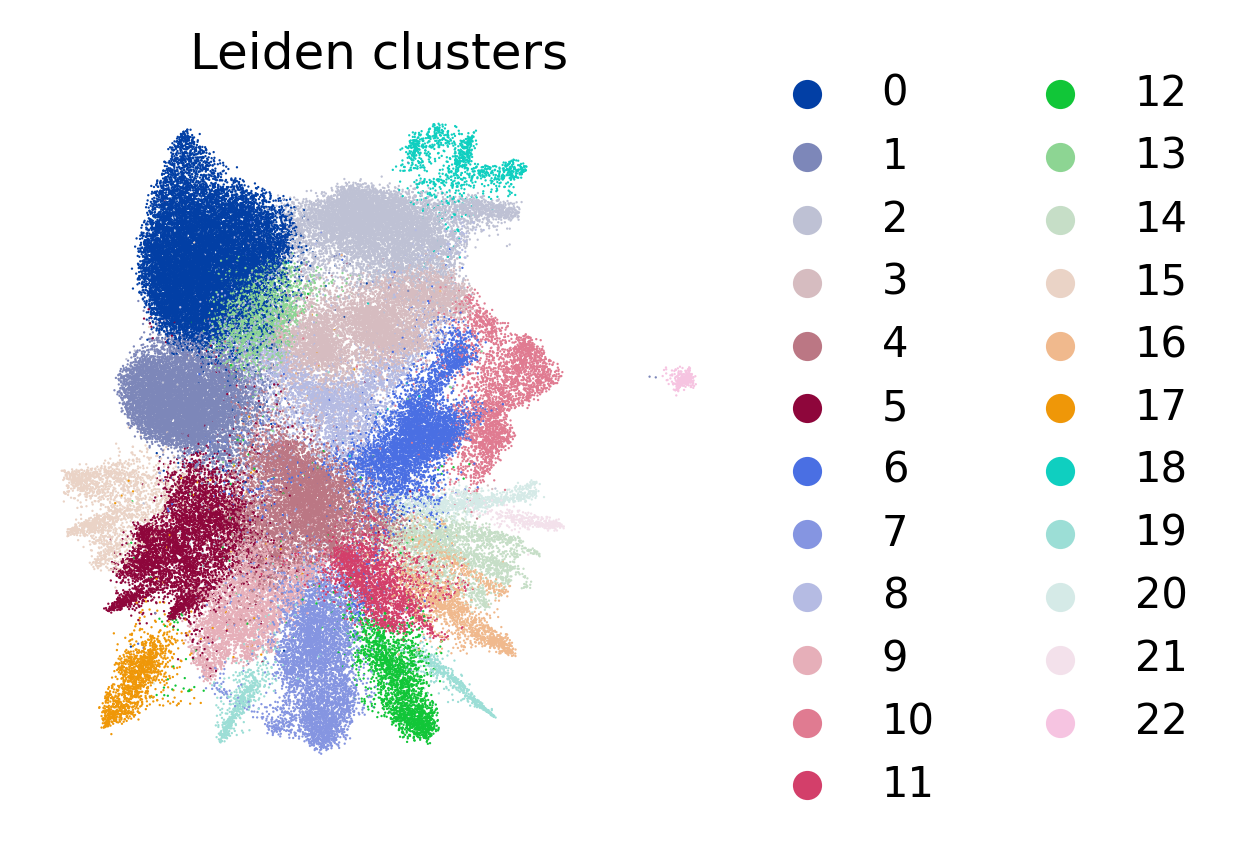

In [12]:
sc.pl.umap(adata, color = 'leiden_scVI_1', frameon = False, title = 'Leiden clusters')

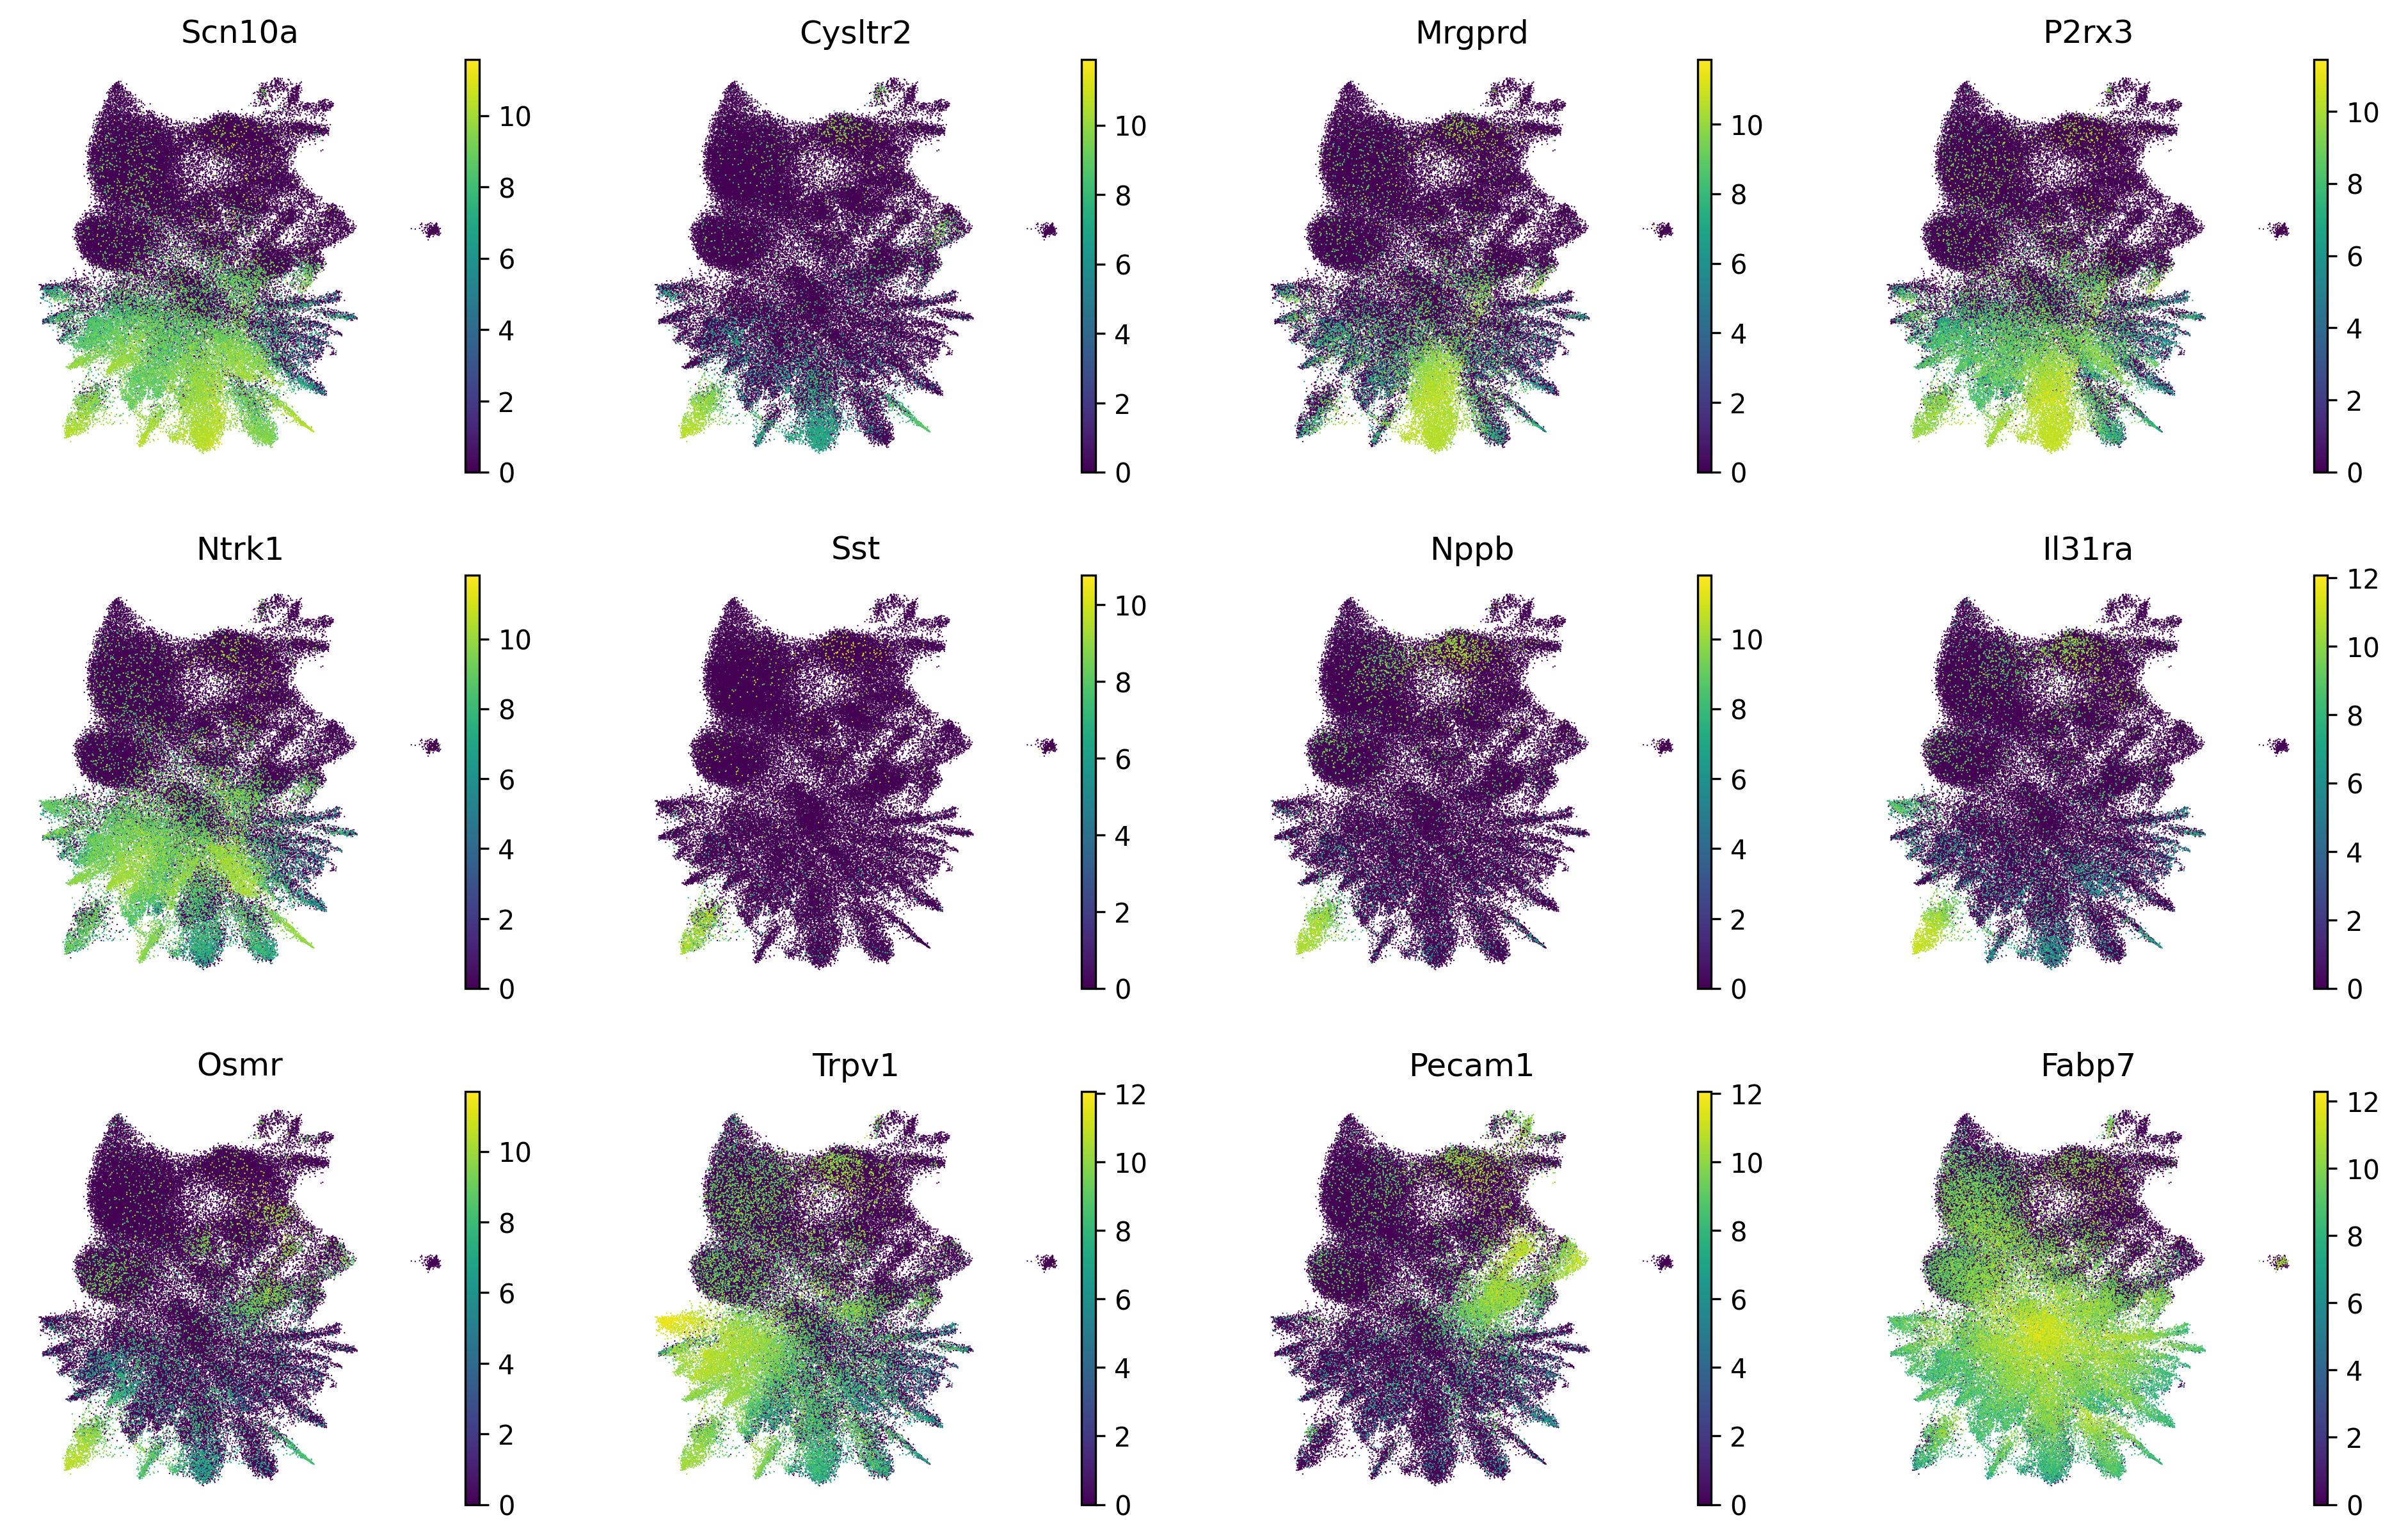

In [13]:
sc.pl.umap(adata, color = ['Scn10a', 'Cysltr2', 'Mrgprd', 'P2rx3', 'Ntrk1', 'Sst', 'Nppb', 'Il31ra', 'Osmr', 'Trpv1', 'Pecam1', 'Fabp7'], frameon = False)

In [14]:
# verify umap is correct cant add key anymore, deprecated

print("adata:", adata.obsm["X_umap"].shape)
print(adata.uns["neighbors"].get("params", {}))

adata: (95966, 2)
{'method': 'umap', 'metric': 'euclidean', 'n_neighbors': 15, 'random_state': 0, 'use_rep': 'X_scVI'}


### export

In [15]:
# umap
#for gene in adata.var_names:
#    sc.pl.umap(adata, color=[gene], show=False, save=None, frameon = False)
#    plt.gcf().savefig(os.path.join(fig_dir, f"UMAP_{gene}.png"), dpi=150, bbox_inches="tight")
#    plt.close()

In [16]:
# fix weird issue with strings in adata.var
for col in adata.var.columns:
    if adata.var[col].dtype == "object":
        adata.var[col] = adata.var[col].apply(
            lambda x: str(x) if not (x is None or (isinstance(x, float) and np.isnan(x))) else ""
        )

In [17]:
# anndata
h5ad_path = os.path.join(output_dir, 'adata-scvi-leiden-annotated-all.h5ad')
adata.write_h5ad(h5ad_path, compression='gzip')

print(h5ad_path)

/home/workspace/projects/drg/data/h5ad/export_03/adata-scvi-leiden-annotated-all.h5ad
